<a href="https://colab.research.google.com/github/Meowmixforme/Kaggle_Machine_Learning_Projects/blob/main/Age_Prediction_Model_Using_Transfer_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
# Imports

import os
import numpy as np
import zipfile
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from google.colab import userdata

In [32]:
# Import dataset using my kaggle API key

uploaded = files.upload()  # Upload kaggle.json

# Set up Kaggle credentials
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!pip install -q kaggle


AttributeError: 'list' object has no attribute 'upload'

In [ ]:
# Download the age prediction dataset
!kaggle datasets download -d mariafrenti/age-prediction

# Extract the dataset
with zipfile.ZipFile("age-prediction.zip", "r") as zip_ref:
    zip_ref.extractall("age_prediction_data")

# List the contents to verify extraction
!ls -la age_prediction_data/

Dataset URL: https://www.kaggle.com/datasets/mariafrenti/age-prediction
License(s): unknown
age-prediction.zip: Skipping, found more recently modified local copy (use --force to force download)
total 16
drwxr-xr-x 4 root root 4096 Jun 17 03:43 .
drwxr-xr-x 1 root root 4096 Jun 17 03:42 ..
drwxr-xr-x 3 root root 4096 Jun 17 03:42 20-50
drwxr-xr-x 3 root root 4096 Jun 17 03:43 age_prediction_up


Creating dataframe with image paths and ages...
Scanning for images...
Processing train directory: age_prediction_data/20-50/20-50/train
  Age 20: 953 images
  Age 21: 1357 images
  Age 22: 1373 images
  Age 23: 1009 images
  Age 24: 1006 images
  Age 25: 1072 images
  Age 26: 922 images
  Age 27: 995 images
  Age 28: 1104 images
  Age 29: 1061 images
  Age 30: 1230 images
  Age 31: 1186 images
  Age 32: 1016 images
  Age 33: 1207 images
  Age 34: 1159 images
  Age 35: 1056 images
  Age 36: 971 images
  Age 37: 1165 images
  Age 38: 1175 images
  Age 39: 1002 images
  Age 40: 984 images
  Age 41: 1060 images
  Age 42: 974 images
  Age 43: 1030 images
  Age 44: 1008 images
  Age 45: 1137 images
  Age 46: 1063 images
  Age 47: 1097 images
  Age 48: 1107 images
  Age 49: 935 images
  Age 50: 1018 images
Processing test directory: age_prediction_data/20-50/20-50/test
  Age 20: 258 images
  Age 21: 271 images
  Age 22: 314 images
  Age 23: 202 images
  Age 24: 228 images
  Age 25: 291 image

,Filepath,Age
0,age_prediction_data/20-50/20-50/train/49/13070...,49
1,age_prediction_data/20-50/20-50/train/31/16665...,31
2,age_prediction_data/20-50/20-50/train/40/14238...,40
3,age_prediction_data/20-50/20-50/test/21/34522.jpg,21
4,age_prediction_data/20-50/20-50/train/22/16059...,22


Age distribution:
Age
20    1211
21    1628
22    1687
23    1211
24    1234
25    1363
26    1163
27    1132
28    1308
29    1332
30    1403
31    1464
32    1245
33    1457
34    1371
35    1287
36    1186
37    1400
38    1368
39    1194
40    1231
41    1341
42    1178
43    1253
44    1222
45    1351
46    1223
47    1301
48    1308
49    1144
50    1244
Name: count, dtype: int64


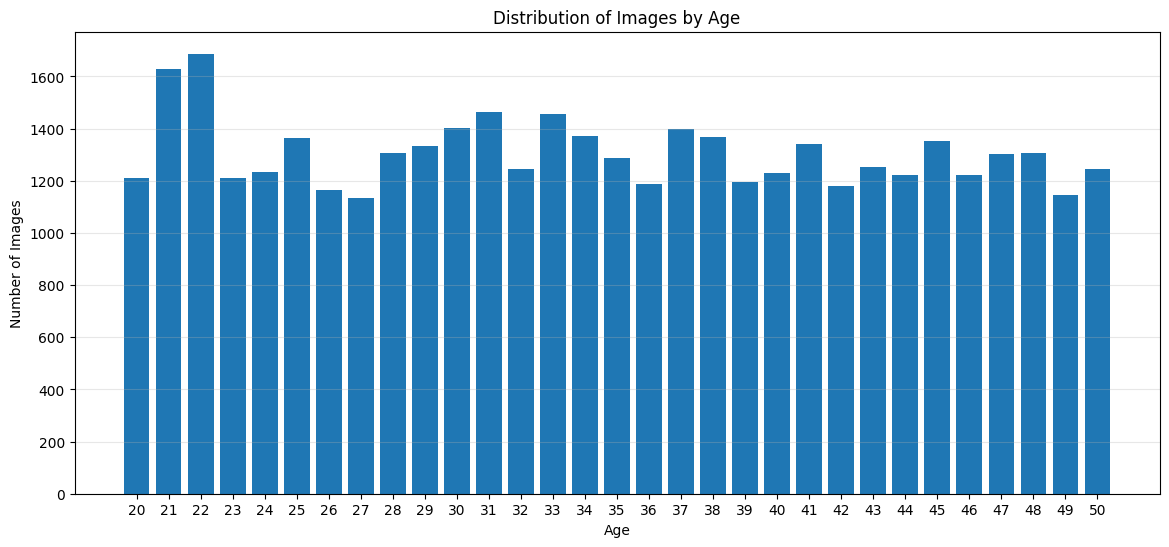

In [ ]:
# Set up paths to the 20-50 dataset
image_dir = Path('./age_prediction_data/20-50/20-50')

# Create DataFrame with file paths and ages
def create_image_dataframe(image_dir):
    filepaths = []
    ages = []

    print("Scanning for images...")

    # Process train directory
    train_dir = image_dir / 'train'
    if train_dir.exists():
        print(f"Processing train directory: {train_dir}")
        for age_dir in sorted(train_dir.glob('[0-9]*')):
            try:
                age = int(age_dir.name)
                image_count = 0
                for img_path in age_dir.glob('*.jpg'):
                    filepaths.append(str(img_path))
                    ages.append(age)
                    image_count += 1
                print(f"  Age {age}: {image_count} images")
            except ValueError as e:
                print(f"Skipping directory {age_dir.name} - not a valid age: {e}")

    # Process test directory
    test_dir = image_dir / 'test'
    if test_dir.exists():
        print(f"Processing test directory: {test_dir}")
        for age_dir in sorted(test_dir.glob('[0-9]*')):
            try:
                age = int(age_dir.name)
                image_count = 0
                for img_path in age_dir.glob('*.jpg'):
                    filepaths.append(str(img_path))
                    ages.append(age)
                    image_count += 1
                print(f"  Age {age}: {image_count} images")
            except ValueError as e:
                print(f"Skipping directory {age_dir.name} - not a valid age: {e}")

    print(f"Found {len(filepaths)} images across {len(set(ages))} different age categories")

    image_df = pd.DataFrame({
        'Filepath': filepaths,
        'Age': ages
    })

    return image_df

# Create dataframe with all images
print("Creating dataframe with image paths and ages...")
images = create_image_dataframe(image_dir)
print(f"Total images found: {len(images)}")

if len(images) > 0:
    images = images.sample(frac=1.0, random_state=42).reset_index(drop=True)
    # Display sample of the dataframe
    print("Sample of the image dataframe:")
    display(images.head())

    # Display age distribution
    age_counts = images['Age'].value_counts().sort_index()
    print("Age distribution:")
    print(age_counts)

    plt.figure(figsize=(14, 6))
    plt.bar(age_counts.index, age_counts.values)
    plt.xlabel('Age')
    plt.ylabel('Number of Images')
    plt.title('Distribution of Images by Age')
    plt.xticks(range(20, 51))
    plt.grid(axis='y', alpha=0.3)
    plt.show()
else:
    print("No images found. Please check the dataset structure.")

In [ ]:
# Decide on sample size based on available resources
# For initial testing, we'll use 10,000 images
sample_size = 10000
image_df = images.sample(min(len(images), sample_size), random_state=42).reset_index(drop=True)
print(f"Using {len(image_df)} images for training and testing")

# Create train/validation/test split
train_df, temp_df = train_test_split(image_df, train_size=0.7, shuffle=True, random_state=42)
val_df, test_df = train_test_split(temp_df, train_size=0.5, shuffle=True, random_state=42)

print(f"Training set: {len(train_df)} images")
print(f"Validation set: {len(val_df)} images")
print(f"Test set: {len(test_df)} images")

Using 10000 images for training and testing
Training set: 7000 images
Validation set: 1500 images
Test set: 1500 images


In [ ]:
# Enhanced data augmentation for training
train_generator = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Just rescaling for validation and test
val_test_generator = ImageDataGenerator(rescale=1./255)

# Create data generators
train_images = train_generator.flow_from_dataframe(
    dataframe=train_df,
    x_col='Filepath',
    y_col='Age',
    target_size=(120, 120),
    color_mode='rgb',
    class_mode='raw',
    batch_size=32,
    shuffle=True,
    seed=42
)

val_images = val_test_generator.flow_from_dataframe(
    dataframe=val_df,
    x_col='Filepath',
    y_col='Age',
    target_size=(120, 120),
    color_mode='rgb',
    class_mode='raw',
    batch_size=32,
    shuffle=False
)

test_images = val_test_generator.flow_from_dataframe(
    dataframe=test_df,
    x_col='Filepath',
    y_col='Age',
    target_size=(120, 120),
    color_mode='rgb',
    class_mode='raw',
    batch_size=32,
    shuffle=False
)

Found 7000 validated image filenames.
Found 1500 validated image filenames.
Found 1500 validated image filenames.


In [ ]:
# Create a transfer learning model with MobileNetV2
def create_transfer_learning_model():
    # Load pre-trained MobileNetV2
    base_model = MobileNetV2(
        input_shape=(120, 120, 3),
        include_top=False,
        weights='imagenet'
    )

    # Freeze base model layers
    base_model.trainable = False

    # Create new model on top
    inputs = tf.keras.Input(shape=(120, 120, 3))
    x = base_model(inputs, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(512, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(1, activation='linear')(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    return model

# Create the model
model = create_transfer_learning_model()
print("Using transfer learning model with MobileNetV2")

# Display model summary
model.summary()

<ipython-input-18-2891182917>:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Using transfer learning model with MobileNetV2


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 120, 120, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,048,513 (11.63 MB)

 Trainable params: 788,993 (3.01 MB)

 Non-trainable params: 2,259,520 (8.62 MB)

In [ ]:
# Learning rate schedule
initial_learning_rate = 0.001
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate,
    decay_steps=100,
    decay_rate=0.96,
    staircase=True
)
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

# Compile model
model.compile(
    optimizer=optimizer,
    loss='mse',
    metrics=['mae']
)

# Create callbacks with updated .keras format
checkpoint_path = "age_model_checkpoint.keras"  # Updated to .keras format
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        filepath=checkpoint_path,
        save_best_only=True,
        monitor='val_loss'
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=5,
        min_lr=0.00001
    )
]

In [ ]:
# Train model
print("Starting model training...")
history = model.fit(
    train_images,
    validation_data=val_images,
    epochs=40,  # Increase for higher accuracy
    callbacks=callbacks
)

Starting model training...
Epoch 1/40
219/219 ━━━━━━━━━━━━━━━━━━━━ 139s 588ms/step - loss: 76.8584 - mae: 7.2313 - val_loss: 76.2862 - val_mae: 7.3328 - learning_rate: 9.2160e-04
Epoch 2/40
219/219 ━━━━━━━━━━━━━━━━━━━━ 127s 581ms/step - loss: 77.3958 - mae: 7.2979 - val_loss: 70.1926 - val_mae: 6.9834 - learning_rate: 8.4935e-04
Epoch 3/40
219/219 ━━━━━━━━━━━━━━━━━━━━ 124s 564ms/step - loss: 75.6568 - mae: 7.2000 - val_loss: 71.5619 - val_mae: 7.1625 - learning_rate: 7.8276e-04
Epoch 4/40
219/219 ━━━━━━━━━━━━━━━━━━━━ 122s 558ms/step - loss: 78.3230 - mae: 7.3687 - val_loss: 71.1489 - val_mae: 7.1123 - learning_rate: 7.2139e-04
Epoch 5/40
219/219 ━━━━━━━━━━━━━━━━━━━━ 120s 547ms/step - loss: 76.1807 - mae: 7.2509 - val_loss: 70.8260 - val_mae: 7.0905 - learning_rate: 6.6483e-04
Epoch 6/40
219/219 ━━━━━━━━━━━━━━━━━━━━ 124s 567ms/step - loss: 74.2618 - mae: 7.1398 - val_loss: 70.7450 - val_mae: 7.1078 - learning_rate: 5.8820e-04
Epoch 7/40
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step - loss:

TypeError: This optimizer was created with a `LearningRateSchedule` object as its `learning_rate` constructor argument, hence its learning rate is not settable. If you need the learning rate to be settable, you should instantiate the optimizer with a float `learning_rate` argument.

In [ ]:
# Plot training history
plt.figure(figsize=(12, 5))

# Plot loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.title('Loss During Training')

# Plot MAE
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.title('MAE During Training')

plt.tight_layout()
plt.show()

In [ ]:
# Evaluate the model
print("Evaluating model on test data...")
test_loss, test_mae = model.evaluate(test_images, verbose=1)
print(f"Test Loss (MSE): {test_loss:.4f}")
print(f"Test MAE: {test_mae:.4f}")

# Make predictions and calculate metrics
predicted_ages = np.squeeze(model.predict(test_images))
true_ages = test_images.labels

mse = mean_squared_error(true_ages, predicted_ages)
rmse = np.sqrt(mse)
mae = mean_absolute_error(true_ages, predicted_ages)
r2 = r2_score(true_ages, predicted_ages)

print(f"Test MSE: {mse:.4f}")
print(f"Test RMSE: {rmse:.4f}")
print(f"Test MAE: {mae:.4f}")
print(f"Test R² Score: {r2:.4f}")

# Calculate baseline/null model metrics
null_rmse = np.sqrt(np.mean((true_ages - np.mean(true_ages))**2))
print(f"Null/Baseline Model Test RMSE: {null_rmse:.4f}")
print(f"Improvement over baseline: {(null_rmse - rmse)/null_rmse:.2%}")

In [ ]:
# Visualise predictions
plt.figure(figsize=(10, 7))
plt.scatter(true_ages, predicted_ages, alpha=0.5)
plt.plot([min(true_ages), max(true_ages)], [min(true_ages), max(true_ages)], 'r--')
plt.xlabel('True Age')
plt.ylabel('Predicted Age')
plt.title('True Age vs Predicted Age')
plt.grid(True)
plt.tight_layout()
plt.show()

# Save the model using the new Keras format
model.save('age_prediction_model.keras')  # Updated to .keras format
print("Initial model saved as 'age_prediction_model.keras'")

In [ ]:
# Fine-tuning the transfer learning model
print("\nFine-tuning the model by unfreezing some layers...")

# Unfreeze the top layers of the base model
base_model = model.layers[1]
base_model.trainable = True

# Freeze all the layers except the top 30
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompile with a lower learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),  # Much lower learning rate
    loss='mse',
    metrics=['mae']
)

In [ ]:
# Continue training for a few more epochs
fine_tune_history = model.fit(
    train_images,
    validation_data=val_images,
    epochs=20,  # Increased from 10 to 20 for better fine-tuning
    callbacks=[
        EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True
        ),
        ModelCheckpoint(
            filepath="age_model_fine_tuned.keras",  # Updated to .keras format
            save_best_only=True,
            monitor='val_loss'
        )
    ]
)

In [ ]:
# Evaluate after fine-tuning
test_loss, test_mae = model.evaluate(test_images, verbose=1)
print(f"After fine-tuning - Test Loss (MSE): {test_loss:.4f}")
print(f"After fine-tuning - Test MAE: {test_mae:.4f}")

# Make predictions with fine-tuned model
ft_predicted_ages = np.squeeze(model.predict(test_images))
ft_mse = mean_squared_error(true_ages, ft_predicted_ages)
ft_rmse = np.sqrt(ft_mse)
ft_mae = mean_absolute_error(true_ages, ft_predicted_ages)
ft_r2 = r2_score(true_ages, ft_predicted_ages)

print(f"After fine-tuning - Test MSE: {ft_mse:.4f}")
print(f"After fine-tuning - Test RMSE: {ft_rmse:.4f}")
print(f"After fine-tuning - Test MAE: {ft_mae:.4f}")
print(f"After fine-tuning - Test R² Score: {ft_r2:.4f}")

# Compare before and after fine-tuning
print("\nComparison before and after fine-tuning:")
print(f"RMSE: {rmse:.4f} → {ft_rmse:.4f}")
print(f"MAE: {mae:.4f} → {ft_mae:.4f}")
print(f"R²: {r2:.4f} → {ft_r2:.4f}")

# Visualise final predictions
plt.figure(figsize=(10, 7))
plt.scatter(true_ages, ft_predicted_ages, alpha=0.5, color='green')
plt.plot([min(true_ages), max(true_ages)], [min(true_ages), max(true_ages)], 'r--')
plt.xlabel('True Age')
plt.ylabel('Predicted Age')
plt.title('True Age vs Predicted Age (Fine-tuned Model)')
plt.grid(True)
plt.tight_layout()
plt.show()

# Save fine-tuned model using the new format
model.save('age_prediction_model_fine_tuned.keras')  # Updated to .keras format
print("Fine-tuned model saved as 'age_prediction_model_fine_tuned.keras'")

In [ ]:
# Calculate error by age group
age_errors = pd.DataFrame({
    'True_Age': true_ages,
    'Predicted_Age': ft_predicted_ages,
    'Error': np.abs(true_ages - ft_predicted_ages)
})

age_group_errors = age_errors.groupby(pd.cut(age_errors['True_Age'],
                                            bins=range(20, 52, 5))).agg({
    'Error': ['mean', 'std', 'count']
})

print("Error analysis by age group:")
print(age_group_errors)

# Plot error by age
plt.figure(figsize=(12, 6))
plt.scatter(true_ages, np.abs(true_ages - ft_predicted_ages), alpha=0.5)
plt.xlabel('True Age')
plt.ylabel('Absolute Error')
plt.title('Absolute Error by Age')
plt.grid(True)
plt.show()